In [53]:
!pip install keras

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import keras
import tensorflow as tf

In [55]:
!pip install tensorflow

# **IPL Score Prediction using Deep Learning**

**In the fast-paced world of IPL, where every run and decision can change the outcome of a match, predicting scores in real time has become both exciting and valuable. Deep learning, with its ability to process massive amounts of historical and live match data, is revolutionizing the way fans, analysts and even teams anticipate results. By uncovering complex patterns that humans or traditional methods might miss, deep learning offers highly accurate score forecasts, making it a powerful tool for enhancing the thrill and strategy of the game.**

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import keras
import tensorflow as tf

In [57]:
df = pd.read_csv('ipl_data.csv')
df

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76009,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,121,7,19.2,40,0,40,12,129
76010,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,127,7,19.3,46,0,46,12,129
76011,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,128,7,19.4,47,0,47,12,129
76012,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian,129,7,19.5,48,0,47,13,129


In [58]:
df.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [60]:
df.isnull().sum()

mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64

In [61]:
df.shape

(76014, 15)

In [62]:
df.dtypes

mid                 int64
date               object
venue              object
bat_team           object
bowl_team          object
batsman            object
bowler             object
runs                int64
wickets             int64
overs             float64
runs_last_5         int64
wickets_last_5      int64
striker             int64
non-striker         int64
total               int64
dtype: object

In [63]:
df.isnull().any()

mid               False
date              False
venue             False
bat_team          False
bowl_team         False
batsman           False
bowler            False
runs              False
wickets           False
overs             False
runs_last_5       False
wickets_last_5    False
striker           False
non-striker       False
total             False
dtype: bool

In [64]:
df.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


## **Exploratory Data Analysis**

We will do Exploratory Data Analysis (EDA) to analyze how many unique matches have been played at each venue by counting distinct match IDs for every venue. Then, we’ll visualize this data using a horizontal bar chart to see which venues host the most matches.

In [65]:
df = df.copy()
matches_per_venue = df[['mid', 'venue']].drop_duplicates()
matches_count = matches_per_venue['venue'].value_counts()


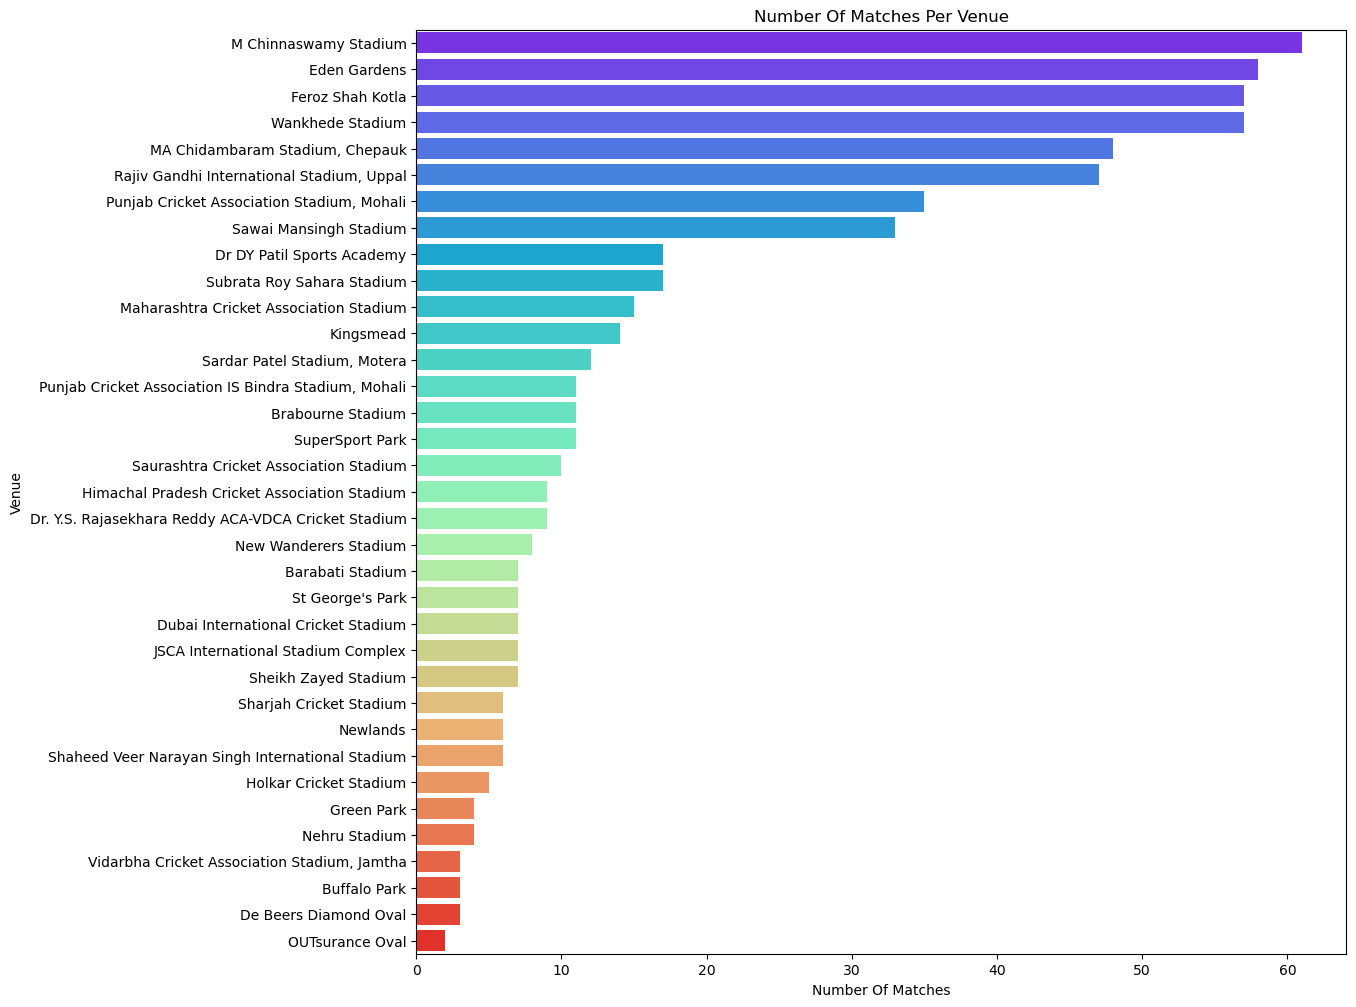

In [66]:
import warnings
warnings.simplefilter('ignore')


plt.figure(figsize=(12, 12))
sns.barplot(x=matches_count.values, y=matches_count.index, palette='rainbow')
plt.title('Number Of Matches Per Venue')
plt.xlabel('Number Of Matches')
plt.ylabel('Venue')
plt.show()

## Then we’ll identify the top 10 batsmen with the highest runs and display this information using a horizontal bar chart.

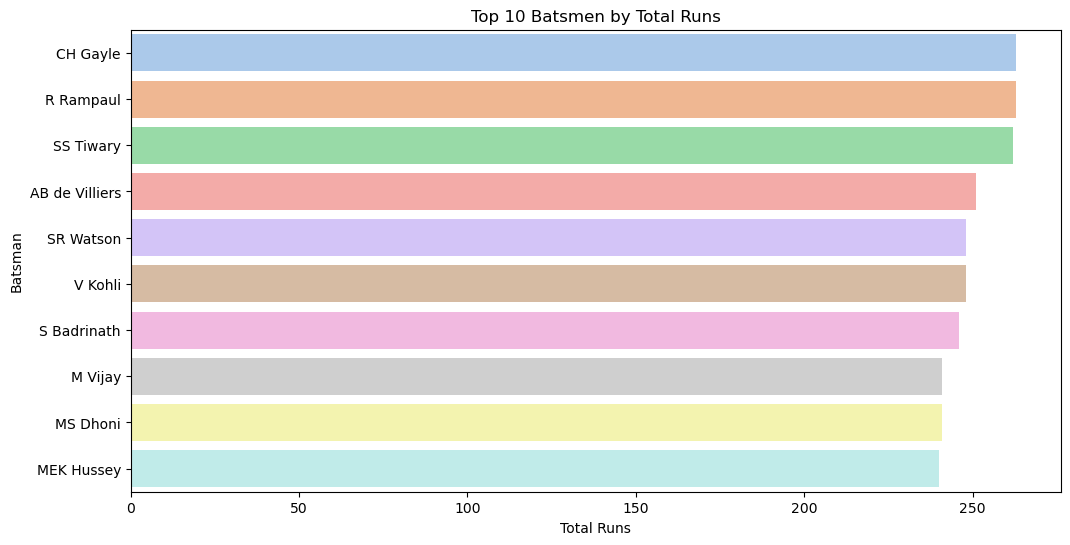

In [67]:
runs_by_batsman = df.groupby('batsman')['runs'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=runs_by_batsman.values, y=runs_by_batsman.index,palette="pastel")
plt.title('Top 10 Batsmen by Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.show()

## we can do the same for the bowlers, in terms of total wickets

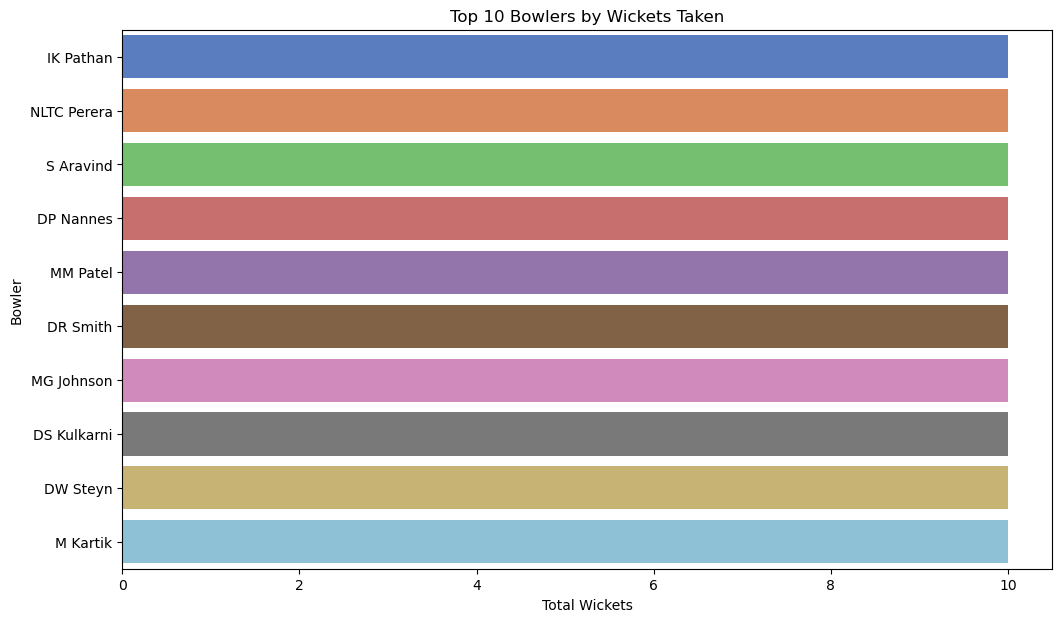

In [68]:
wickets_by_bowler = df.groupby('bowler')['wickets'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=wickets_by_bowler.values, y=wickets_by_bowler.index, palette='muted')
plt.title('Top 10 Bowlers by Wickets Taken')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.show()

## **Performing Label Encoding**
We will convert categorical text data into numeric labels using Label Encoding because ML models work with numbers.

In [69]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['bat_team', 'bowl_team', 'venue', 'batsman', 'bowler']

df_encoded = df.copy()

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

## **Performing Feature Selection**
We drop date and mid columns because they are identifiers and don’t provide meaningful information for correlation analysis. By removing these irrelevant columns we focus on features that can reveal relationships useful for modeling or insights. Computing and visualizing correlations helps identify which features are related and can guide feature selection


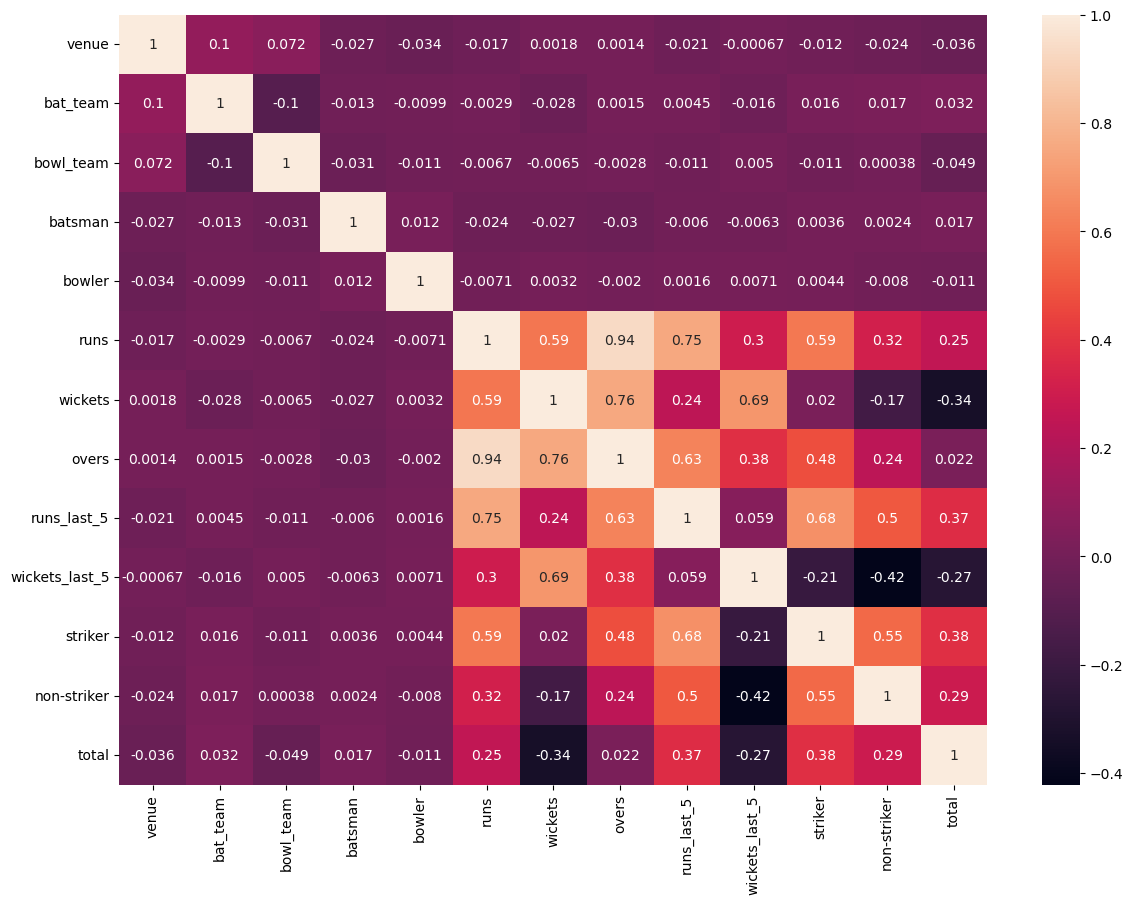

In [70]:
plt.figure(figsize=(14, 10))
df_corr = df_encoded.drop(columns=['date', 'mid'], axis=1)
sns.heatmap(df_corr.corr(), annot=True)
plt.show()

## **Splitting the Data into Training and Testing**
select relevant features and the target variable then split the data into training and testing sets for model building and evaluation

In [71]:
from sklearn.model_selection import train_test_split
feature_cols = ['bat_team', 'bowl_team', 'venue', 'runs', 'wickets', 'overs', 'striker', 'batsman', 'bowler']

X = df_encoded[feature_cols]
y = df_encoded['total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## **Performing Feature scaling**
perform Min-Max scaling on our input features to ensure all the features are on the same scale. It ensures consistent scale and improves model performance. Scaling will be done on both training and testing data using the scaling parameters.

In [72]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Building the Neural Networks**
build neural network using TensorFlow and Keras for regression. After building the model we have compiled the model using the Huber Loss because of the robustness of the regression against outliers.

In [73]:
model = keras.Sequential([
    keras.layers.Input( shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(512, activation='relu'),  
    keras.layers.Dense(216, activation='relu'),  
    keras.layers.Dense(1, activation='linear') 
])

huber_loss = tf.keras.losses.Huber(delta=1.0)  # You can adjust the 'delta' parameter as needed
model.compile(optimizer='adam', loss=huber_loss)

## **Training the Model**
**We train the model on the scaled training data for 10 epochs with a batch size of 50, validating on the test set.**

In [74]:
model.fit(X_train_scaled, y_train, epochs=10, batch_size=50, validation_data=(X_test_scaled, y_test))

Epoch 1/10
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 24.5073 - val_loss: 14.9575
Epoch 2/10
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 14.8773 - val_loss: 14.3501
Epoch 3/10
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 14.7204 - val_loss: 14.5431
Epoch 4/10
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 14.5536 - val_loss: 14.1863
Epoch 5/10
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 14.5069 - val_loss: 14.1525
Epoch 6/10
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 14.4562 - val_loss: 14.1941
Epoch 7/10
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 14.3042 - val_loss: 14.2073
Epoch 8/10
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 14.3406 - val_loss: 13.8751
Epoch 9/10
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 14.2622 - val_loss: 13.8051
Epoch 10/10
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 14.2786 - val_loss: 13.8215


**We can plot the loss and validation loss of the model**

<Axes: >

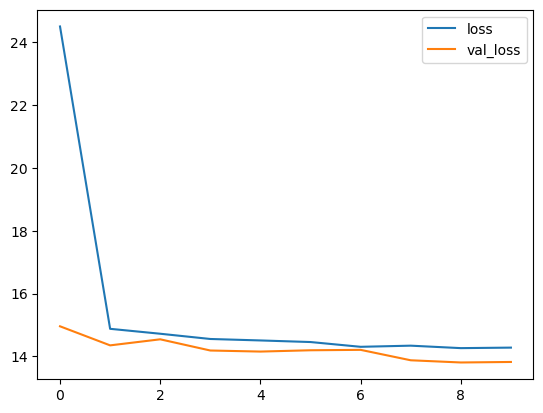

In [75]:
model_losses = pd.DataFrame(model.history.history)
model_losses.plot()

## **Evaluating the Model**
predict scores on test data and evaluate model performance using mean absolute error (MAE).

In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
predictions = model.predict(X_test_scaled)

mean_absolute_error(y_test, predictions)

713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


14.3126220703125